We analyze the regime where certain approximations are valid:
- Bond dimensions
- Maximal Sites

In [3]:
import scipy.linalg as la
import numpy as np
import copy
import time
import random
import matplotlib.pyplot as plt
import pandas as pd
import csv, ast
from qutip import *
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
rng = np.random.default_rng(43)
np.random.seed(43)
random.seed(43)

Given that the maximum number of sites is 100, we examine whether this provides a valid approximation for $\gamma\tau = 10$. We will show that accurately simulating the case $\gamma\tau = 10$ requires more than 100 sites.

In [5]:
Bond15_gammatau10 = pd.read_csv("MeasurementsBond15_gammatau10.csv")
Bond10_gammatau10 = pd.read_csv("MeasurementsBond10_gammatau10.csv")
Bond5_gammatau10 = pd.read_csv("MeasurementsBond5_gammatau10.csv")

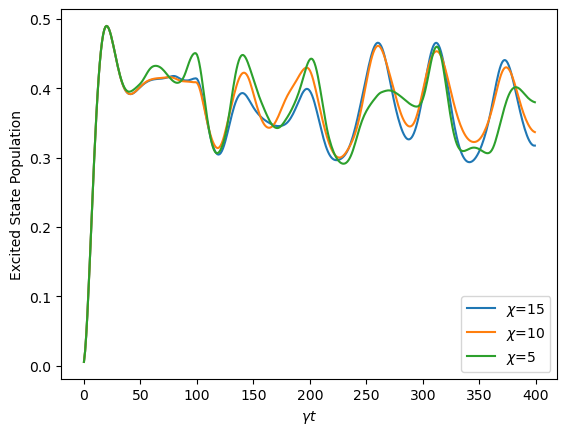

In [8]:
plt.plot([complex(str(x).strip("()")).real for x in Bond15_gammatau10["Es"]], label=r"$\chi$=15")
plt.plot([complex(str(x).strip("()")).real for x in Bond10_gammatau10["Es"]], label=r"$\chi$=10")
plt.plot([complex(str(x).strip("()")).real for x in Bond5_gammatau10["Es"]], label=r"$\chi$=5")
plt.xlabel(r"$\gamma t$")
plt.ylabel("Excited State Population")
plt.legend()

Given that the maximum number of sites is 100, we examine whether this provides a valid approximation for $\gamma\tau = 5$. We will show that accurately simulating the case $\gamma\tau = 5$ requires more than 100 sites. However, for shorter delay times, the approximation becomes more accurate.

In [11]:
Bond10_gammatau5 = pd.read_csv("MeasurementsBond10_gammatau5.csv")
Bond5_gammatau5 = pd.read_csv("MeasurementsBond5_gammatau5.csv")

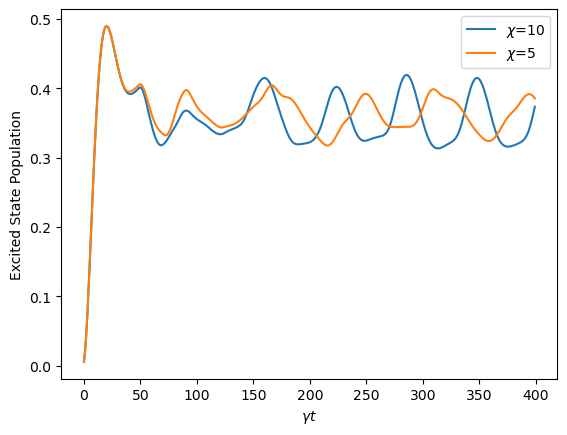

In [13]:
plt.plot([complex(str(x).strip("()")).real for x in Bond10_gammatau5["Es"]],label=r"$\chi$=10")
plt.plot([complex(str(x).strip("()")).real for x in Bond5_gammatau5["Es"]], label=r"$\chi$=5")
plt.xlabel(r"$\gamma t$")
plt.ylabel("Excited State Population")
plt.legend()

In [15]:
Bond10_gammatau1 = pd.read_csv("MeasurementsBond10_gammatau1.csv")
Bond5_gammatau1 = pd.read_csv("MeasurementsBond5_gammatau1.csv")

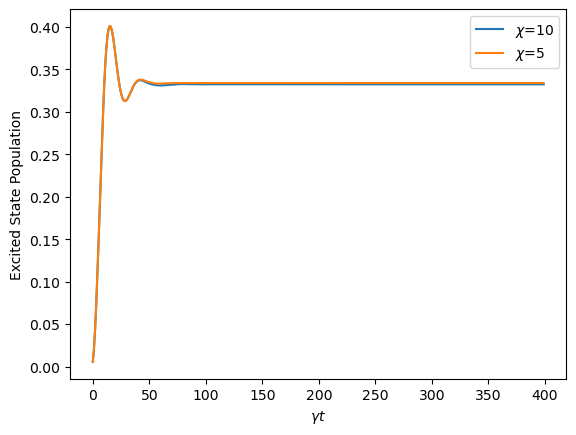

In [17]:
plt.plot([complex(str(x).strip("()")).real for x in Bond10_gammatau1["Es"]],label=r"$\chi$=10")
plt.plot([complex(str(x).strip("()")).real for x in Bond5_gammatau1["Es"]], label=r"$\chi$=5")
plt.xlabel(r"$\gamma t$")
plt.ylabel("Excited State Population")
plt.legend()

Similarly, we examine the case where the input is random and $\gamma \tau = 1.5$. In this case, we observe the quadratures.

In [20]:
import ast
Bond10_gammatau1_5 = pd.read_csv("MeasurementsBond10_gammatau1_5_random.csv") # MeasurementsBond10_gammatau1_5_random
Bond5_gammatau1_5 = pd.read_csv("MeasurementsBond5_gammatau1_5_random.csv")
def extract_pq(x):
    # Convert string like "(array([0.1]), array([0.2]))"
    # into two floats: P, Q
    s = str(x)
    s = s.replace("array", "np.array")
    P, Q = eval(s, {"np": np})
    return float(np.asarray(P).squeeze()), float(np.asarray(Q).squeeze())

B10_P15 = []
B10_Q15 = []
for x in Bond10_gammatau1_5["PQ-15"]:
    p15, q15 = extract_pq(x)
    B10_P15.append(p15)
    B10_Q15.append(q15)

B5_P15 = []
B5_Q15 = []
for x in Bond5_gammatau1_5["PQ-15"]:
    p15, q15 = extract_pq(x)
    B5_P15.append(p15)
    B5_Q15.append(q15)

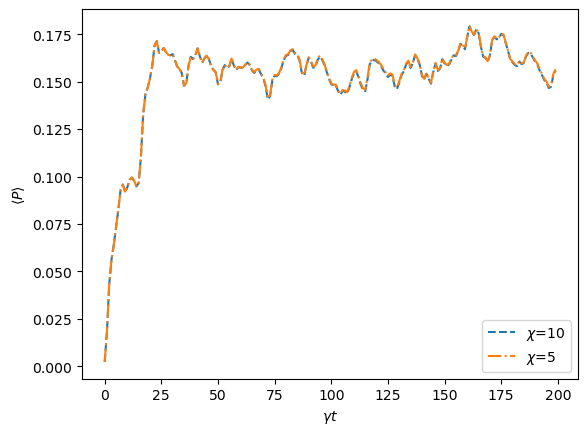

In [22]:
plt.plot(B10_P15,label=r"$\chi$=10", linestyle="--")
plt.plot(B5_P15, label=r"$\chi$=5", linestyle="-.")
plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\langle P \rangle$")
plt.legend()
plt.savefig("Goodregime.png")

Here, we examing the quadratures at $\phi=\pi/3$. 

In [85]:
Bond10_gammatau1_5 = pd.read_csv("MeasurementsBond10_differentquadratures_masked.csv") # MeasurementsBond10_gammatau1_5_random
def extract_pq(x):
    # Convert string like "(array([0.1]), array([0.2]))"
    # into two floats: P, Q
    s = str(x)
    s = s.replace("array", "np.array")
    P, Q = eval(s, {"np": np})
    return float(np.asarray(P).squeeze()), float(np.asarray(Q).squeeze())

B10_P15 = []
B10_Q15 = []
for x in Bond10_gammatau1_5["PQ-15"]:
    p15, q15 = extract_pq(x)
    B10_P15.append(p15)
    B10_Q15.append(q15)

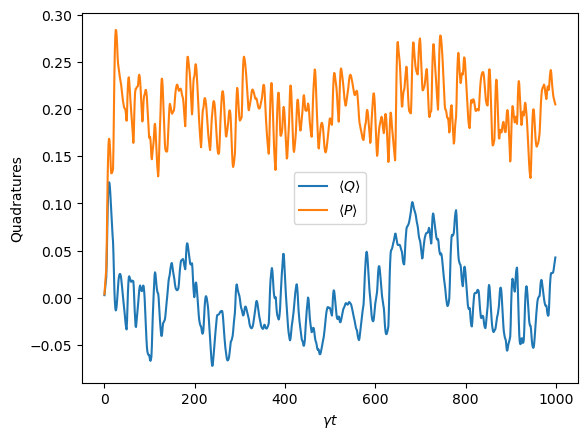

In [87]:
plt.plot(B10_Q15,label=r"$\langle Q \rangle$")
plt.plot(B10_P15,label=r"$\langle P \rangle$")
plt.xlabel(r"$\gamma t$")
plt.ylabel("Quadratures")
plt.legend()

Lastly, we mask the random input 4 times to observe its behavior.

In [90]:
Bond10_gammatau1_5 = pd.read_csv("MeasurementsBond10_gammatau1_5_random_masked.csv")
Bond5_gammatau1_5 = pd.read_csv("MeasurementsBond5_gammatau1_5_random_masked.csv")

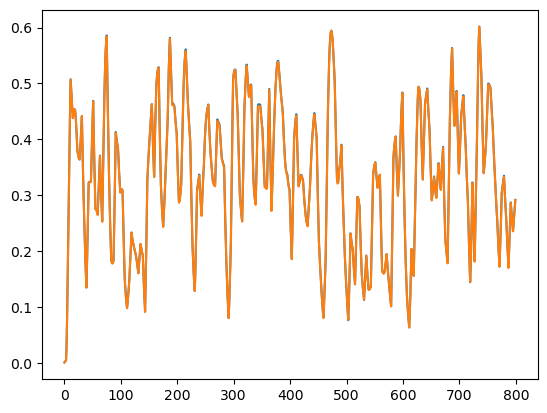

In [92]:
plt.plot([complex(str(x).strip("()")).real for x in Bond5_gammatau1_5["Es"]],label=r"$\chi$=5")
plt.plot([complex(str(x).strip("()")).real for x in Bond10_gammatau1_5["Es"]],label=r"$\chi$=10")

In [94]:
import ast
Bond10_gammatau1_5 = pd.read_csv("MeasurementsBond10_gammatau1_5_random_masked.csv")
Bond5_gammatau1_5 = pd.read_csv("MeasurementsBond5_gammatau1_5_random_masked.csv")
def extract_pq(x):
    # Convert string like "(array([0.1]), array([0.2]))"
    # into two floats: P, Q
    s = str(x)
    s = s.replace("array", "np.array")
    P, Q = eval(s, {"np": np})
    return float(np.asarray(P).squeeze()), float(np.asarray(Q).squeeze())

B10_P15 = []
B10_Q15 = []
for x in Bond10_gammatau1_5["PQ-15"]:
    p15, q15 = extract_pq(x)
    B10_P15.append(p15)
    B10_Q15.append(q15)

B5_P15 = []
B5_Q15 = []
for x in Bond5_gammatau1_5["PQ-15"]:
    p15, q15 = extract_pq(x)
    B5_P15.append(p15)
    B5_Q15.append(q15)

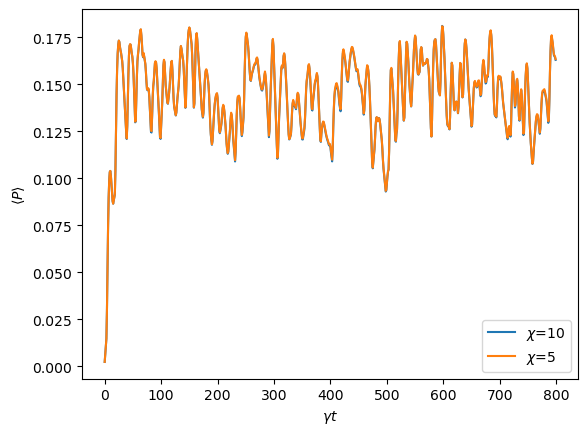

In [96]:
plt.plot(B10_P15,label=r"$\chi$=10")
plt.plot(B5_P15, label=r"$\chi$=5")
plt.xlabel(r"$\gamma t$")
plt.ylabel(r"$\langle P \rangle$")
plt.legend()

In [98]:
x = [0.00071, 0.00020, 0.00015, ]